# E3 — Persistence / routing at \(t^*\)

**Plan reference:** Phase 2, experiment E3.

**Question:** When (by depth) and from where does \(t^*\)'s preference for \(W\) get support?
E2 found a late write-wave; this tests **landing** at the final `=`.

**Method:** tuned-lens W−C at \(t^*\) by layer; OV-weighted attention routing to source regions.
Not causal — E4/E5 patch/ablate nominated bundles.


In [1]:
# %pip install tuned-lens transformer-lens torch matplotlib numpy pandas

from pathlib import Path
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformer_lens as tl
from dataclasses import dataclass
from tuned_lens.nn import TunedLens, Unembed
from IPython.display import display

torch.set_grad_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


## Core functions + prompt bank


In [2]:
"""E3 — Persistence / routing at t* (runnable script; notebook mirrors this)."""

from __future__ import annotations

import json
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformer_lens as tl
from tuned_lens.nn import TunedLens, Unembed

torch.set_grad_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    OUT_DIR = Path(__file__).resolve().parent / "E3_outputs"
except NameError:
    OUT_DIR = Path("E3_outputs")
OUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Shared setup (E1/E2 prompt bank)
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class Item:
    name: str
    a: int
    b: int
    W_str: str
    C_str: str


ITEMS = [
    Item("ops_12+15", 12, 15, " 25", " 27"),
    Item("ops_8+7", 8, 7, " 14", " 15"),
    Item("ops_11+12", 11, 12, " 22", " 23"),
    Item("ops_9+6", 9, 6, " 14", " 15"),
    Item("ops_13+14", 13, 14, " 26", " 27"),
    Item("ops_4+5", 4, 5, " 8", " 9"),
    Item("ops_16+10", 16, 10, " 24", " 26"),
    Item("ops_3+8", 3, 8, " 10", " 11"),
]

CUE = " Wait, let me recompute."
FILLER_UNIT = " ..."
REGION_NAMES = ("W", "W_window", "revision", "ops1", "ops2", "pre_W", "between_cue_ops2", "other")


def find_first_W_pos(str_toks: list[str], W_str: str) -> int:
    eq_seen = False
    for i, t in enumerate(str_toks):
        if t == " =":
            eq_seen = True
            continue
        if eq_seen and t == W_str:
            return i
    raise ValueError(f"W token {W_str!r} not found")


def find_t_star(str_toks: list[str]) -> int:
    eq = [i for i, t in enumerate(str_toks) if t == " ="]
    if not eq:
        raise ValueError("no ' =' token")
    return eq[-1]


def w_direction(model, W_str: str, C_str: str) -> torch.Tensor:
    W_id = model.to_single_token(W_str)
    C_id = model.to_single_token(C_str)
    return model.W_U[:, W_id] - model.W_U[:, C_id]


def n_tokens(model, text: str) -> int:
    return len(model.to_str_tokens(text)) - 1


def build_prompt(model, item: Item, with_cue: bool = True) -> str:
    prefix = f"{item.a} + {item.b} ={item.W_str}."
    suffix = f" {item.a} + {item.b} ="
    middle = CUE if with_cue else FILLER_UNIT * n_tokens(model, CUE)
    return prefix + middle + suffix


def tag_regions(str_toks: list[str], item: Item, W_pos: int, t_star: int) -> dict[str, list[int]]:
    eq_positions = [i for i, t in enumerate(str_toks) if t == " ="]
    if len(eq_positions) < 2:
        raise ValueError("expected two '=' tokens")
    eq1 = eq_positions[0]

    ops1_pos = list(range(eq1 - 3, eq1)) if eq1 >= 3 else []
    ops2_pos = list(range(t_star - 3, t_star)) if t_star >= 3 else []

    rev_start = None
    for j, t in enumerate(str_toks):
        if t == " Wait":
            rev_start = j
            break
    rev_end = (ops2_pos[0] - 1) if ops2_pos else (t_star - 1)
    revision = list(range(rev_start, rev_end + 1)) if rev_start is not None else []

    W_window = [p for p in range(max(0, W_pos - 2), min(len(str_toks), W_pos + 3))]
    pre_W = list(range(1, W_pos))
    between = list(range(revision[-1] + 1, ops2_pos[0])) if revision and ops2_pos else []

    assigned = set()
    regions: dict[str, list[int]] = {}
    for name, pos_list in [
        ("W", [W_pos]),
        ("W_window", W_window),
        ("revision", revision),
        ("ops1", ops1_pos),
        ("ops2", ops2_pos),
        ("pre_W", pre_W),
        ("between_cue_ops2", between),
    ]:
        regions[name] = sorted(set(pos_list))
        assigned.update(regions[name])

    regions["other"] = [j for j in range(len(str_toks)) if j not in assigned and j != t_star]
    return regions


@dataclass
class E3Result:
    item: str
    with_cue: bool
    str_toks: list[str]
    W_pos: int
    t_star: int
    final_score: float
    top1: str
    regions: dict[str, list[int]]
    tuned_at_tstar: np.ndarray  # [n_layers+1]
    tuned_at_W: np.ndarray
    attn_raw: np.ndarray  # [n_layers, seq]
    ov_raw: np.ndarray  # [n_layers, seq]
    attn_by_region: np.ndarray  # [n_layers, n_regions]
    ov_by_region: np.ndarray
    ov_by_layer_head: np.ndarray  # [n_layers, n_heads]
    random_ov_by_region: np.ndarray | None = None


def compute_ov_to_w(
    model,
    cache,
    layer: int,
    t_star: int,
    w: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray]:
    """Per-source OV-weighted and raw attention from t* at one layer."""
    n_heads = model.cfg.n_heads
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0]  # [head, dest, src]
    v = cache[f"blocks.{layer}.attn.hook_v"][0]  # [pos, head, d_head]
    W_O = model.W_O[layer]
    z = torch.einsum("phd,hdm->phm", v, W_O)
    dot_zw = torch.einsum("phd,d->ph", z, w)
    attn = pattern[:, t_star, :].detach().float().cpu().numpy()  # [head, src]
    ov = attn * dot_zw.T.detach().float().cpu().numpy()  # [head, src]
    attn_src = attn.sum(0)
    ov_src = ov.sum(0)
    ov_head = ov.sum(1)
    return attn_src, ov_src, ov_head


def region_aggregate(values: np.ndarray, regions: dict[str, list[int]], names: tuple[str, ...]) -> np.ndarray:
    out = np.zeros(len(names), dtype=np.float64)
    for i, name in enumerate(names):
        idx = regions.get(name, [])
        if idx:
            out[i] = values[idx].sum()
    return out


def emergence_depth(scores: np.ndarray) -> int | None:
    """First layer index where score > 0 and stays > 0 through end."""
    for i in range(len(scores) - 1):
        if scores[i] > 0 and np.all(scores[i:] > 0):
            return i
    return None


def run_e3(model, tuned_lens, item: Item, with_cue: bool = True, n_random: int = 8, seed: int = 0) -> E3Result:
    prompt = build_prompt(model, item, with_cue=with_cue)
    tokens = model.to_tokens(prompt)
    str_toks = model.to_str_tokens(prompt)
    W_id = model.to_single_token(item.W_str)
    C_id = model.to_single_token(item.C_str)
    w = w_direction(model, item.W_str, item.C_str)
    W_pos = find_first_W_pos(str_toks, item.W_str)
    t_star = find_t_star(str_toks)
    regions = tag_regions(str_toks, item, W_pos, t_star)

    logits, cache = model.run_with_cache(tokens)
    logit_vec = logits[0, t_star]
    final_score = float(logit_vec[W_id] - logit_vec[C_id])
    top1 = model.to_string([int(logit_vec.argmax())])

    n_layers = model.cfg.n_layers
    seq = len(str_toks)

    tuned_at_tstar = np.zeros(n_layers + 1, dtype=np.float64)
    tuned_at_W = np.zeros(n_layers + 1, dtype=np.float64)
    for L in range(n_layers):
        hidden = cache[f"blocks.{L}.hook_resid_pre"]
        tl_logits = tuned_lens.forward(hidden, L)
        tuned_at_tstar[L] = float(tl_logits[0, t_star, W_id] - tl_logits[0, t_star, C_id])
        tuned_at_W[L] = float(tl_logits[0, W_pos, W_id] - tl_logits[0, W_pos, C_id])
    tuned_at_tstar[-1] = final_score
    tuned_at_W[-1] = float(logits[0, W_pos, W_id] - logits[0, W_pos, C_id])

    attn_raw = np.zeros((n_layers, seq), dtype=np.float64)
    ov_raw = np.zeros((n_layers, seq), dtype=np.float64)
    ov_by_layer_head = np.zeros((n_layers, model.cfg.n_heads), dtype=np.float64)
    attn_by_region = np.zeros((n_layers, len(REGION_NAMES)), dtype=np.float64)
    ov_by_region = np.zeros((n_layers, len(REGION_NAMES)), dtype=np.float64)

    for L in range(n_layers):
        a_src, o_src, o_head = compute_ov_to_w(model, cache, L, t_star, w)
        attn_raw[L] = a_src
        ov_raw[L] = o_src
        ov_by_layer_head[L] = o_head
        attn_by_region[L] = region_aggregate(a_src, regions, REGION_NAMES)
        ov_by_region[L] = region_aggregate(o_src, regions, REGION_NAMES)

    rand_ov_region = None
    if n_random > 0:
        gen = torch.Generator(device=w.device)
        gen.manual_seed(seed)
        rand_ov_region = np.zeros((n_layers, len(REGION_NAMES)), dtype=np.float64)
        for _ in range(n_random):
            r = torch.randn(w.shape[0], generator=gen, device=w.device, dtype=w.dtype)
            r = r / r.norm() * w.norm()
            for L in range(n_layers):
                _, o_src, _ = compute_ov_to_w(model, cache, L, t_star, r)
                rand_ov_region[L] += region_aggregate(o_src, regions, REGION_NAMES)
        rand_ov_region /= n_random

    return E3Result(
        item=item.name,
        with_cue=with_cue,
        str_toks=str_toks,
        W_pos=W_pos,
        t_star=t_star,
        final_score=final_score,
        top1=top1,
        regions=regions,
        tuned_at_tstar=tuned_at_tstar,
        tuned_at_W=tuned_at_W,
        attn_raw=attn_raw,
        ov_raw=ov_raw,
        attn_by_region=attn_by_region,
        ov_by_region=ov_by_region,
        ov_by_layer_head=ov_by_layer_head,
        random_ov_by_region=rand_ov_region,
    )


def plot_depth_profiles(results: list[E3Result], title: str, fname: str):
    n_layers = len(results[0].tuned_at_tstar) - 1
    xs = np.arange(n_layers + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for res in results:
        axes[0].plot(xs, res.tuned_at_tstar, alpha=0.35, lw=1)
        axes[1].plot(xs, res.tuned_at_W, alpha=0.35, lw=1)
    mean_t = np.mean([r.tuned_at_tstar for r in results], axis=0)
    mean_w = np.mean([r.tuned_at_W for r in results], axis=0)
    axes[0].plot(xs, mean_t, "k", lw=2.5, label="mean")
    axes[1].plot(xs, mean_w, "k", lw=2.5, label="mean")
    for ax, ylab in zip(axes, ["t* (final =)", "impulse W"]):
        ax.axhline(0, color="gray", ls="--", lw=0.8)
        ax.set_xlabel("layer (last = final)")
        ax.set_ylabel("tuned-lens W−C")
        ax.set_xticks(xs)
    axes[0].set_title("Preference at probe t*")
    axes[1].set_title("Preference at impulse W")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=150)
    plt.close(fig)


def plot_region_heatmap(mat: np.ndarray, title: str, fname: str, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(mat.T, aspect="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(REGION_NAMES)))
    ax.set_yticklabels(REGION_NAMES)
    ax.set_xlabel("layer")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=150)
    plt.close(fig)


def main():
    print("device:", DEVICE)
    model = tl.HookedTransformer.from_pretrained("gpt2", device=DEVICE, fold_ln=False)
    model.eval()
    tuned_lens = TunedLens.from_unembed_and_pretrained(
        unembed=Unembed(model), lens_resource_id="gpt2"
    ).to(DEVICE)

    for it in ITEMS:
        model.to_single_token(it.W_str)
        model.to_single_token(it.C_str)

    print("Running 8-item E3...")
    results = [run_e3(model, tuned_lens, it, with_cue=True) for it in ITEMS]
    base = results[0]

    print(f"demo prompt: {build_prompt(model, ITEMS[0])!r}")
    print(f"t*={base.t_star} W_pos={base.W_pos} final_score={base.final_score:.3f} top1={base.top1!r}")
    for name in REGION_NAMES:
        print(f"  {name:18s} {base.regions.get(name, [])}")

    # --- depth profiles ---
    plot_depth_profiles(results, "E3: tuned-lens W−C depth profiles (8 items)", "depth_profiles.png")

    emerge = [emergence_depth(r.tuned_at_tstar) for r in results]
    print("emergence depth at t*:", emerge, "mean", np.nanmean([e for e in emerge if e is not None]))

    # --- OV routing heatmaps (mean over items) ---
    mean_ov_region = np.mean([r.ov_by_region for r in results], axis=0)
    mean_attn_region = np.mean([r.attn_by_region for r in results], axis=0)
    mean_rand = np.mean([r.random_ov_by_region for r in results], axis=0)

    vmax = np.max(np.abs(mean_ov_region))
    plot_region_heatmap(mean_ov_region, "Mean OV·w routing to w by region (from t*)", "ov_by_region.png", -vmax, vmax)
    plot_region_heatmap(mean_attn_region, "Mean raw attention mass by region (from t*)", "attn_by_region.png")
    plot_region_heatmap(mean_ov_region - mean_rand, "OV·w minus random-direction control", "ov_minus_random.png", -vmax, vmax)

    # cumulative OV by layer
    cum_ov = np.cumsum(mean_ov_region, axis=0)
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, name in enumerate(REGION_NAMES):
        ax.plot(cum_ov[:, i], label=name)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("layer")
    ax.set_ylabel("cumulative OV·w to region")
    ax.set_title("Cumulative OV-weighted flow by region (mean 8 items)")
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "cum_ov_by_region.png", dpi=150)
    plt.close(fig)

    # per-layer total |OV| and fraction in key regions
    total_abs_ov = np.sum(np.abs(mean_ov_region), axis=1)
    key = ["W", "W_window", "revision", "ops2", "ops1"]
    key_idx = [REGION_NAMES.index(k) for k in key]
    key_frac = np.sum(np.abs(mean_ov_region[:, key_idx]), axis=1) / (total_abs_ov + 1e-12)

    # landing band: layers contributing top 80% of |OV|
    layer_mass = total_abs_ov / (total_abs_ov.sum() + 1e-12)
    order = np.argsort(-layer_mass)
    csum = 0.0
    landing_layers = []
    for L in order:
        landing_layers.append(int(L))
        csum += layer_mass[L]
        if csum >= 0.80:
            break
    landing_band = (min(landing_layers), max(landing_layers))
    print(f"landing band (80% |OV| mass): L{landing_band[0]}–L{landing_band[1]}")

    # top source regions by total |OV|
    region_totals = np.sum(np.abs(mean_ov_region), axis=0)
    rank = sorted(zip(REGION_NAMES, region_totals), key=lambda x: -x[1])
    print("region |OV| rank:", [(n, f"{v:.3f}") for n, v in rank])

    # top heads at late layers
    late = slice(8, 12)
    mean_ov_head = np.mean([r.ov_by_layer_head[late] for r in results], axis=0)  # [4, heads]
    flat = []
    for li, L in enumerate(range(8, 12)):
        for h in range(model.cfg.n_heads):
            flat.append((L, h, mean_ov_head[li, h]))
    flat.sort(key=lambda x: -abs(x[2]))
    print("top 10 (layer, head) by |mean OV·w| L8–L11:", flat[:10])

    # no_cue control on baseline
    nocue = run_e3(model, tuned_lens, ITEMS[0], with_cue=False, n_random=0)
    print(f"no_cue final_score={nocue.final_score:.3f} vs cued={base.final_score:.3f}")

    # summary table
    rows = []
    for r in results:
        rows.append({
            "item": r.item,
            "final_score": r.final_score,
            "top1": r.top1,
            "emergence": emergence_depth(r.tuned_at_tstar),
            "ov_W": r.ov_by_region[:, REGION_NAMES.index("W")].sum(),
            "ov_ops2": r.ov_by_region[:, REGION_NAMES.index("ops2")].sum(),
            "ov_revision": r.ov_by_region[:, REGION_NAMES.index("revision")].sum(),
        })
    df = pd.DataFrame(rows)
    df.to_csv(OUT_DIR / "per_item_summary.csv", index=False)
    print(df.to_string(index=False))

  # nominations
    summary = {
        "landing_band_layers": landing_band,
        "top_source_regions": [n for n, _ in rank[:4]],
        "emergence_depths": emerge,
        "mean_final_score": float(np.mean([r.final_score for r in results])),
        "key_region_frac_late": float(np.mean(key_frac[8:])),
    }
    with open(OUT_DIR / "e3_nominations.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("Wrote outputs to", OUT_DIR)
    print("E4/E5 nominations:", json.dumps(summary, indent=2))


## 1. Load model + run 8-item bank


In [3]:
model = tl.HookedTransformer.from_pretrained("gpt2", device=DEVICE, fold_ln=False)
model.eval()
tuned_lens = TunedLens.from_unembed_and_pretrained(unembed=Unembed(model), lens_resource_id="gpt2").to(DEVICE)

results = [run_e3(model, tuned_lens, it, with_cue=True) for it in ITEMS]
base = results[0]
print(f"demo: {build_prompt(model, ITEMS[0])!r}")
print(f"t*={base.t_star} W_pos={base.W_pos} score={base.final_score:.3f} top1={base.top1!r}")
for name in REGION_NAMES:
    print(f"  {name:18s} {base.regions.get(name, [])}")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


demo: '12 + 15 = 25. Wait, let me recompute. 12 + 15 ='
t*=17 W_pos=5 score=4.194 top1=' 25'
  W                  [5]
  W_window           [3, 4, 5, 6, 7]
  revision           [7, 8, 9, 10, 11, 12, 13]
  ops1               [1, 2, 3]
  ops2               [14, 15, 16]
  pre_W              [1, 2, 3, 4]
  between_cue_ops2   []
  other              [0]


## 2. Depth profiles + routing heatmaps


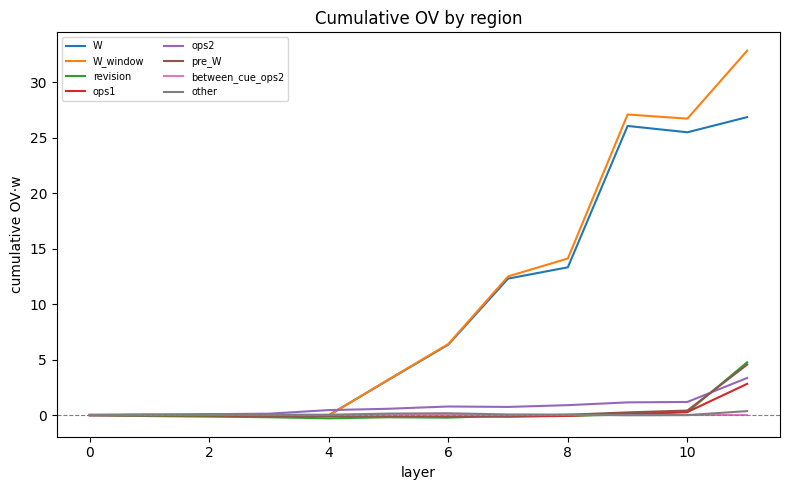

emergence at t*: [5, 6, 6, 6, 6, 1, 1, 0]
landing band (80% |OV|): L5–L11
region rank: [('W_window', 33.773862892296165), ('W', 28.06899247285037), ('revision', 5.448337208013982), ('pre_W', 4.886592034250498), ('ops2', 3.508329671807587), ('ops1', 3.1514427041984163), ('other', 0.7840399243868887), ('between_cue_ops2', 0.0)]
top heads L8–L11: [(9, 9, 12.575456142425537), (11, 0, 9.145892402157187), (10, 7, -6.311944484710693), (11, 11, 2.6818240648135543), (10, 2, 2.504594773054123), (11, 8, 1.996077574789524), (10, 1, 1.917323125526309), (11, 4, 1.3951602093875408), (11, 10, -1.1014776825904846), (10, 0, 0.8981532249599695)]


no_cue score=3.003 vs cued=4.194


,item,final_score,top1,emergence,ov_W,ov_ops2,ov_revision
0,ops_12+15,4.194221,25,5,37.377452,12.358774,16.046797
1,ops_8+7,2.444412,14,6,24.496428,-5.172698,-7.480097
2,ops_11+12,1.868966,22,6,19.203620,-3.652803,-1.211344
3,ops_9+6,2.768471,14,6,24.483464,-5.166214,-7.639309
4,ops_13+14,1.262815,26,6,13.871483,0.889071,-0.057865
5,ops_4+5,2.113895,8,1,16.857214,6.066833,3.811389
6,ops_16+10,4.489054,24,1,49.844419,7.108630,13.872285
7,ops_3+8,2.520422,10,0,28.830191,14.420279,20.791743


In [4]:
OUT_DIR.mkdir(exist_ok=True)
plot_depth_profiles(results, "E3 depth profiles", "depth_profiles.png")

mean_ov_region = np.mean([r.ov_by_region for r in results], axis=0)
mean_attn_region = np.mean([r.attn_by_region for r in results], axis=0)
mean_rand = np.mean([r.random_ov_by_region for r in results], axis=0)
vmax = np.max(np.abs(mean_ov_region))

plot_region_heatmap(mean_ov_region, "Mean OV·w by region", "ov_by_region.png", -vmax, vmax)
plot_region_heatmap(mean_attn_region, "Mean raw attention by region", "attn_by_region.png")
plot_region_heatmap(mean_ov_region - mean_rand, "OV·w minus random dir", "ov_minus_random.png", -vmax, vmax)

cum_ov = np.cumsum(mean_ov_region, axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(REGION_NAMES):
    ax.plot(cum_ov[:, i], label=name)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("layer"); ax.set_ylabel("cumulative OV·w"); ax.set_title("Cumulative OV by region")
ax.legend(fontsize=7, ncol=2); fig.tight_layout(); plt.show()

emerge = [emergence_depth(r.tuned_at_tstar) for r in results]
print("emergence at t*:", emerge)

total_abs_ov = np.sum(np.abs(mean_ov_region), axis=1)
layer_mass = total_abs_ov / (total_abs_ov.sum() + 1e-12)
order = np.argsort(-layer_mass); csum = 0.0; landing_layers = []
for L in order:
    landing_layers.append(int(L)); csum += layer_mass[L]
    if csum >= 0.80: break
print(f"landing band (80% |OV|): L{min(landing_layers)}–L{max(landing_layers)}")

region_totals = np.sum(np.abs(mean_ov_region), axis=0)
print("region rank:", sorted(zip(REGION_NAMES, region_totals), key=lambda x: -x[1]))

late = slice(8, 12)
mean_ov_head = np.mean([r.ov_by_layer_head[late] for r in results], axis=0)
flat = [(L, h, mean_ov_head[li, h]) for li, L in enumerate(range(8, 12)) for h in range(model.cfg.n_heads)]
flat.sort(key=lambda x: -abs(x[2]))
print("top heads L8–L11:", flat[:10])

nocue = run_e3(model, tuned_lens, ITEMS[0], with_cue=False, n_random=0)
print(f"no_cue score={nocue.final_score:.3f} vs cued={base.final_score:.3f}")

rows = [{"item": r.item, "final_score": r.final_score, "top1": r.top1, "emergence": emergence_depth(r.tuned_at_tstar),
         "ov_W": r.ov_by_region[:, REGION_NAMES.index("W")].sum(),
         "ov_ops2": r.ov_by_region[:, REGION_NAMES.index("ops2")].sum(),
         "ov_revision": r.ov_by_region[:, REGION_NAMES.index("revision")].sum()} for r in results]
df = pd.DataFrame(rows)
display(df)
df.to_csv(OUT_DIR / "per_item_summary.csv", index=False)
